In [21]:
# 필요한 라이브러리들 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# csv를 읽어와서 Pandas DataFrame으로 저장

data = pd.read_csv("./data/2000_2001_hitter.csv")
data2 = pd.read_csv("./data/2002_2013_hitter.csv")
data3 = pd.read_csv("./data/2014_hitter.csv")

# 여러 데이터프레임을 리스트 [] 로 묶어서 전달해야 합니다.
df_combined = pd.concat([data, data2, data3], axis=0)

# 인덱스가 중복될 수 있으므로 초기화해주는 것이 깔끔합니다.
df_combined = df_combined.reset_index(drop=True)

# 확인
df_combined.sample(5)

,YrPlayer,Year,Rank,Player,Team,AVG,G,PA,AB,H,...,TA,RC,RC/27,wOBA,XR,R,SAC,MH,RISP,PH-BA
496,2011최준석,2011,28,최준석,두산,0.271,124,485,421,114,...,0.755486,66.616082,5.517283,0.346081,65.188,49.0,2.0,25.0,0.263,0.286
295,2006고동진,2006,36,고동진,한화,0.241,120,414,370,89,...,0.563574,38.242319,3.419015,0.276403,39.090,40.0,6.0,19.0,0.213,0.500
627,2014이병규,2014,34,이병규,LG,0.306,116,450,360,110,...,0.996255,84.218844,8.179528,0.408892,79.566,66.0,3.0,27.0,0.327,0.125
116,2002마르티네스,2002,28,마르티네스,LG,0.279,109,468,409,114,...,0.778846,66.192308,5.620102,0.342933,66.590,59.0,0.0,34.0,0.301,0.000
532,2012김강민,2012,27,김강민,SK,0.272,123,474,427,116,...,0.564024,48.060253,3.794231,0.299786,47.494,49.0,11.0,32.0,0.243,0.400


In [23]:
#파일을 합치기


In [24]:
# 변수 선택
X = df_combined[['OPS','ISO','SECA','TA','RC','RC/27','wOBA','XR']]
y = df_combined['YrPlayer']

print(X.shape, y.shape)
X.head()
y.head()
print(df_combined)

(649, 8) (649,)
      YrPlayer  Year  Rank Player Team    AVG    G   PA   AB    H  ...  \
0     2000박종호   2000     1   박종호   현대   0.340  121  541  441  150  ...   
1     2000김동주   2000     2   김동주   두산   0.339  127  539  469  159  ...   
2     2000브리또   2000     3   브리또   SK   0.338  103  452  405  137  ...   
3     2000송지만   2000     4   송지만   한화   0.338  120  530  468  158  ...   
4    2000데이비스   2000     5  데이비스   한화   0.334  107  458  419  140  ...   
..         ...   ...   ...    ...  ...    ...  ...  ...  ...  ...  ...   
644    2014이범호  2014    51    이범호  KIA  0.269  105  406  350   94  ...   
645    2014모창민  2014    52    모창민   NC  0.263  122  468  419  110  ...   
646    2014오지환  2014    53    오지환   LG  0.262  113  464  397  104  ...   
647    2014조동화  2014    54    조동화   SK  0.262  125  522  443  116  ...   
648    2014김재호  2014    55    김재호   두산  0.252  122  421  341   86  ...   

           TA          RC     RC/27      wOBA       XR     R   SAC    MH  \
0    0.976667  100.

In [25]:
# 데이터 분포 확인(박스플롯)
sns.boxplot(X,y)
plt.show()

TypeError: boxplot() takes from 0 to 1 positional arguments but 2 were given

In [26]:
# 데이터 스케일링
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_combined_scaler = scaler.fit_transform(X)
print(df_combined_scaler)

[[ 0.97614887 -0.07422939  0.10417649 ...  1.20484091  1.11880719
   1.21433377]
 [ 1.89711625  1.67989079  1.05416505 ...  1.75823146  1.89486616
   1.85744936]
 [ 1.10761611  0.61991005 -0.16048453 ...  1.1714146   1.13904003
   0.42420225]
 ...
 [-0.42233048 -0.05169927  0.77350431 ... -0.32541846 -0.43538549
  -0.33597768]
 [-1.46085838 -1.39601302 -1.62726689 ... -1.37885116 -1.47288829
  -1.11957047]
 [-1.28467954 -1.24146838 -0.64887581 ... -1.19083305 -1.21125882
  -1.3345048 ]]


In [27]:
### 여러개의 클러스터링 갯수를 List로 입력 받아 각각의 실루엣 계수를 면적으로 시각화한 함수
def visualize_silhouette(cluster_lists, X_features): 
    
    from sklearn.datasets import make_blobs
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import math
    
    # 입력값으로 클러스터링 갯수들을 리스트로 받아서, 각 갯수별로 클러스터링을 적용하고 실루엣 개수를 구함
    n_cols = len(cluster_lists)
    
    # plt.subplots()으로 리스트에 기재된 클러스터링 수만큼의 sub figures를 가지는 axs 생성 
    fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)
    
    # 리스트에 기재된 클러스터링 갯수들을 차례로 iteration 수행하면서 실루엣 개수 시각화
    for ind, n_cluster in enumerate(cluster_lists):
        
        # KMeans 클러스터링 수행하고, 실루엣 스코어와 개별 데이터의 실루엣 값 계산. 
        clusterer = KMeans(n_clusters = n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(X_features)
        
        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)
        
        y_lower = 10
        axs[ind].set_title('Number of Cluster : '+ str(n_cluster)+'\n' \
                          'Silhouette Score :' + str(round(sil_avg,3)) )
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])  # Clear the yaxis labels / ticks
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        
        # 클러스터링 갯수별로 fill_betweenx( )형태의 막대 그래프 표현. 
        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels==i]
            ith_cluster_sil_values.sort()
            
            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i
            
            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values, \
                                facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10
            
        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")

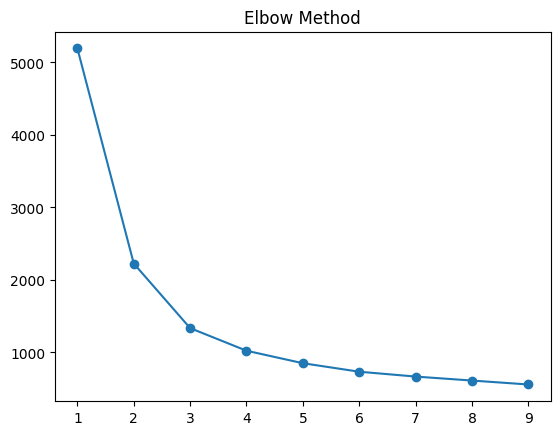

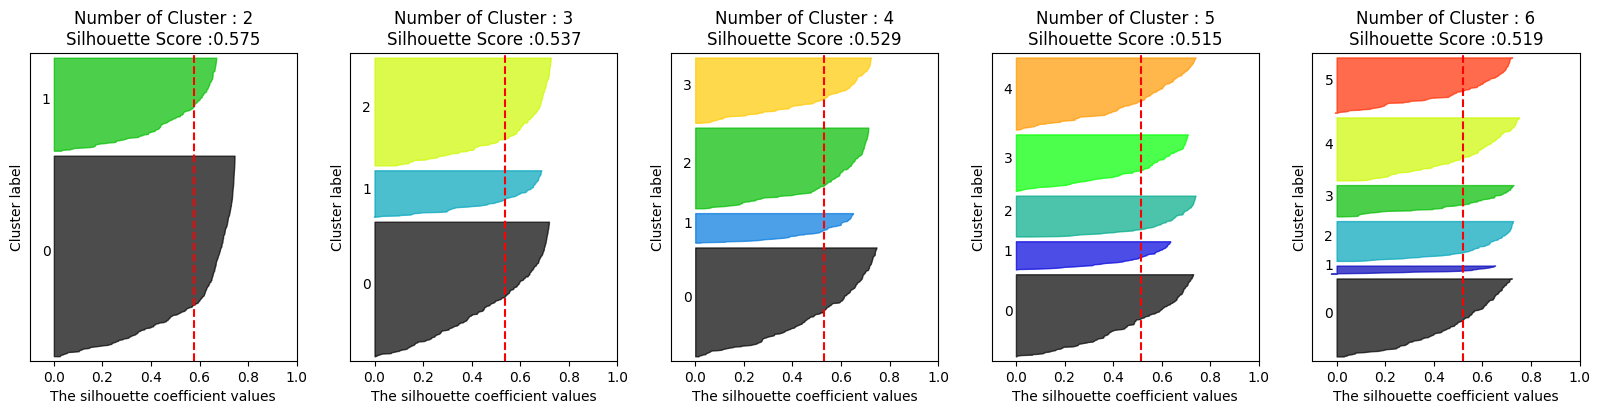

In [28]:
# --- 1. Elbow Method로 후보 확인 ---
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for n in range(1, 10):
    km = KMeans(n_clusters=n, init='k-means++', random_state=42, n_init=10)
    km.fit(df_combined_scaler)
    inertia.append(km.inertia_)

# Elbow 그래프 시각화 (어디서 꺾이는지 확인용)
plt.plot(range(1, 10), inertia, marker='o')
plt.title('Elbow Method')
plt.show()

visualize_silhouette([2,3,4,5,6], X)

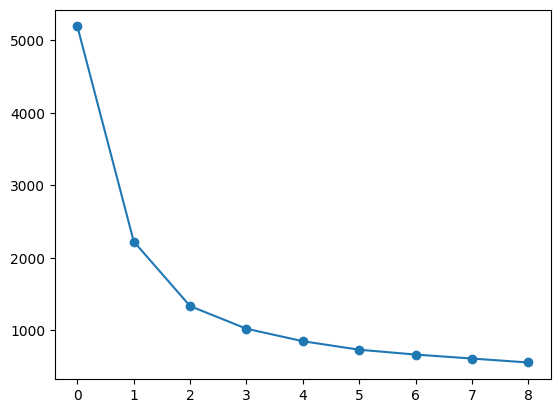

In [29]:
plt.plot(inertia, marker = 'o')
plt.show()

In [31]:
# 엘보우 기법으로 최적의 k 찾기
k = 3
km = KMeans(n_clusters=k, random_state=42)
cluster = km.fit_predict(X)
cluster

array([0, 0, 2, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 1, 1, 2, 2,
       1, 1, 0, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 0,
       2, 0, 0, 0, 2, 2, 2, 0, 2, 2, 0, 2, 2, 2, 1, 0, 2, 2, 2, 2, 0, 1,
       2, 2, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 0, 1, 1, 1, 1, 2, 1, 1, 1, 2,
       1, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 1, 2, 2, 2, 1,
       2, 1, 2, 2, 0, 1, 2, 2, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 0, 0, 2,
       0, 0, 0, 0, 0, 0, 2, 2, 2, 0, 0, 2, 2, 2, 0, 1, 2, 0, 2, 2, 2, 2,
       1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 0, 2, 2, 0, 2, 2, 0,
       0, 2, 0, 0, 2, 2, 0, 2, 1, 0, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2,
       0, 2, 2, 1, 1, 1, 2, 1, 2, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 0, 0,
       0, 2, 1, 2, 2, 1, 2, 2, 2, 1, 0, 2, 1, 1, 1, 2, 2, 2, 1, 1, 2, 2,
       1, 2, 1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 2, 2, 2,
       0, 2, 2, 2, 2, 1, 1, 2, 1, 2, 2, 1, 2, 2, 1, 2, 1, 2, 1, 2, 1, 1,
       1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 0,

In [32]:
# 군집화 결과 분석 

# 데이터프레임 생성
df = pd.DataFrame(X, columns=X.columns)
df['cluster'] = cluster
df.head()


,OPS,ISO,SECA,TA,RC,RC/27,wOBA,XR,cluster
0,0.917819,0.149660,0.297052,0.976667,100.354529,8.286154,0.400138,92.804,0
1,1.017141,0.264392,0.379531,1.063830,115.473840,9.306847,0.431993,105.000,0
2,0.931997,0.195062,0.274074,0.931655,86.204956,8.224501,0.400969,77.820,2
3,1.031229,0.284188,0.423077,1.110092,119.916981,9.811389,0.436688,107.594,0
4,0.932665,0.231504,0.324582,0.923588,82.605677,7.125729,0.394586,80.284,2


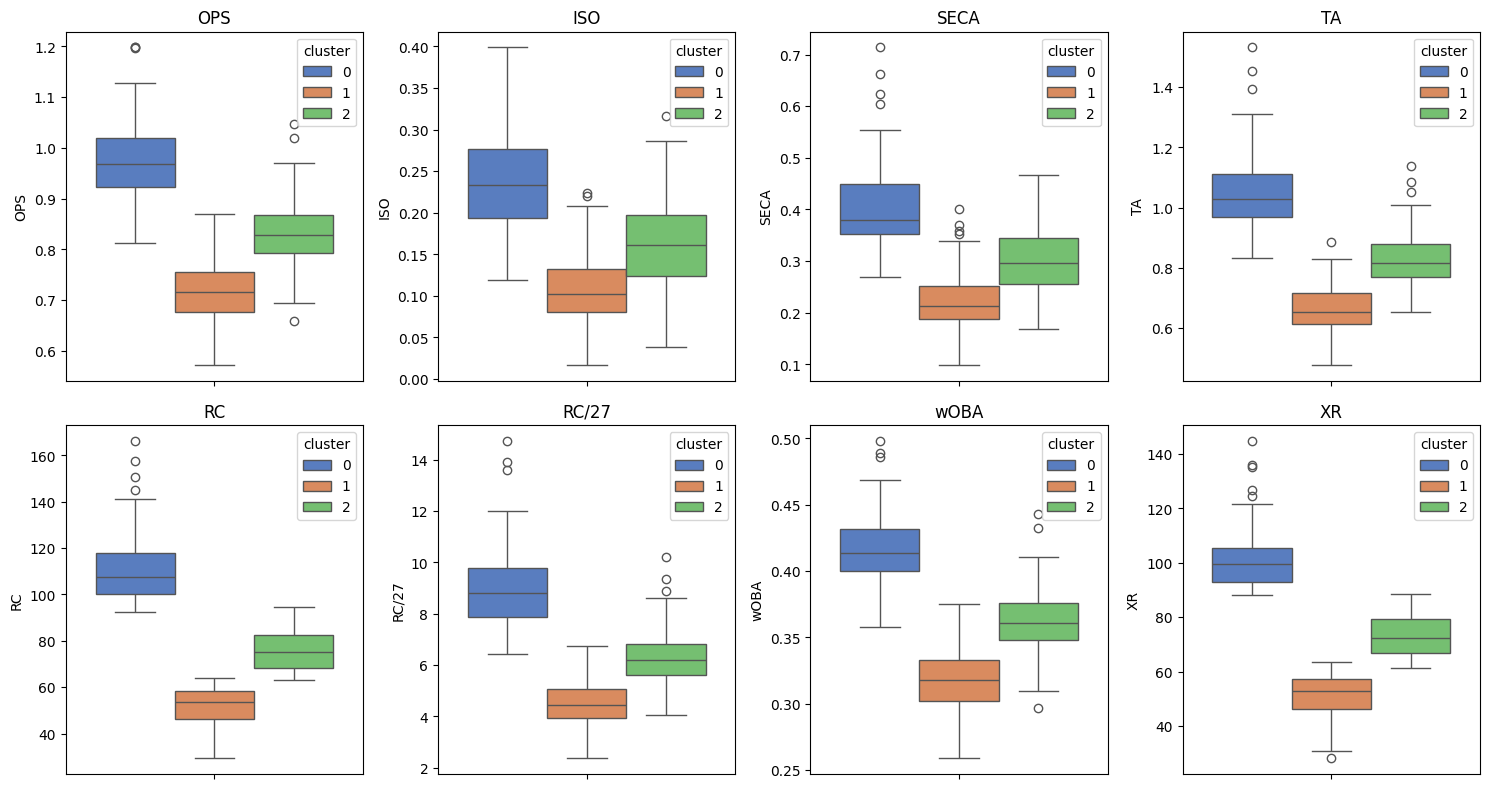

In [33]:
# 군집의 데이터 특징 분석
cols = df.columns[:-1]

plt.figure(figsize=(15,8))
for i, col in enumerate(cols):
    plt.subplot(2,4,i+1)
    sns.boxplot(data=df, y=col, hue='cluster', palette='muted')
    plt.title(col)
plt.tight_layout()

In [ ]:
# 시각화를 보고 한줄 정리

타자들이 득점에 얼마나 기여했는지를 보여주기 때문에 0,1,2는 기여가 높은걸로 그룹이 만들어진거 같다
0: 공격지표와 득점에 가장 많이 기여한 그룹이므로 야구를 굉장히 잘하는 리그 선수들일 것 같음
1: 평균 이상의 준수한 장타력을 가지고 있어서 주전급 선수들일 것 같음
2: 0,1군집에 비해서 득점등 다른 수치들이 낮아서 후보 선수들일 것 같음

In [44]:
# 데이터프레임에 개별 데이터 실루엣 계수 컬럼 추가
df['silhouette'] = silhouette_samples(X, cluster)
df

,OPS,ISO,SECA,TA,RC,RC/27,wOBA,XR,cluster,silhouette
0,0.917819,0.149660,0.297052,0.976667,100.354529,8.286154,0.400138,92.804,0,0.469920
1,1.017141,0.264392,0.379531,1.063830,115.473840,9.306847,0.431993,105.000,0,0.683237
2,0.931997,0.195062,0.274074,0.931655,86.204956,8.224501,0.400969,77.820,2,0.592959
3,1.031229,0.284188,0.423077,1.110092,119.916981,9.811389,0.436688,107.594,0,0.664014
4,0.932665,0.231504,0.324582,0.923588,82.605677,7.125729,0.394586,80.284,2,0.643264
...,...,...,...,...,...,...,...,...,...,...
644,0.857000,0.228571,0.377143,0.884328,64.894286,6.441712,0.369291,63.468,2,0.150327
645,0.733000,0.150358,0.276850,0.676647,53.028291,4.138046,0.319970,55.644,1,0.669427
646,0.767000,0.151134,0.355164,0.818182,64.147759,5.463689,0.336344,63.404,2,0.087227
647,0.655000,0.063205,0.146727,0.539359,48.898621,3.520701,0.293759,48.544,1,0.723784


In [43]:
# 잘못 군집화 된 클러스터
df.loc[df['silhouette']<0]

,OPS,ISO,SECA,TA,RC,RC/27,wOBA,XR,cluster,silhouette
403,0.88,0.213992,0.378601,0.893733,92.54482,6.771572,0.379616,88.85,0,-0.002569


In [ ]:
# C
df['player'] = y

In [51]:
df['player'][df.groupby('cluster')['silhouette'].idxmax()]
df.loc[df.groupby('cluster')['silhouette'].idxmax()]

,OPS,ISO,SECA,TA,RC,RC/27,wOBA,XR,cluster,silhouette,player
385,0.920000,0.133333,0.356250,1.051051,112.786726,8.956593,0.402632,103.260,0,0.685948,2009정근우
311,0.709000,0.035040,0.150943,0.636364,49.367442,4.676916,0.321981,49.220,1,0.725000,2007전준호
29,0.846768,0.220930,0.341860,0.849231,78.544183,6.406927,0.366886,75.858,2,0.717977,2000심재학


In [65]:
# 전체 주성분 계산

from sklearn.decomposition import PCA

pca = PCA()
pca1 = pd.DataFrame(pca.fit_transform(X))
pca1


,0,1,2,3,4,5,6,7
0,36.098541,-0.489253,-0.065670,-0.097843,-0.000186,0.013923,0.016414,0.002200
1,55.543320,-0.961889,-0.349091,0.009199,-0.039561,0.007873,0.008502,0.002094
2,15.640106,-2.951113,0.288124,-0.047061,-0.053490,-0.004311,0.009919,0.002914
3,60.627914,-1.891408,-0.451540,0.045133,-0.014668,0.001926,0.007577,0.002272
4,14.440405,1.363163,0.713896,0.006711,-0.065054,0.022244,0.018606,-0.003393
...,...,...,...,...,...,...,...,...
644,-9.946296,-0.100626,1.003882,0.090292,0.001457,0.003748,0.012968,0.001180
645,-24.163179,2.044082,0.179384,0.054289,-0.002153,0.005581,0.000341,-0.002495
646,-10.612705,0.623194,0.252314,0.069214,0.068817,0.014131,0.013150,-0.001578
647,-31.938109,-0.466057,-0.887829,-0.021867,-0.006074,-0.008197,-0.011891,-0.000385


In [55]:
# 컬럼별 설명된 분산 비율 확인
explained_variance = pca.explained_variance_ratio_
explained_variance

array([9.97120600e-01, 2.55561772e-03, 3.18699741e-04, 3.53166772e-06,
       1.19366885e-06, 2.55501753e-07, 9.60949703e-08, 5.75258342e-09])

In [56]:
# 누적분산 확인
cumulative_variance = explained_variance.cumsum()
cumulative_variance

array([0.9971206 , 0.99967622, 0.99999492, 0.99999845, 0.99999964,
       0.9999999 , 0.99999999, 1.        ])

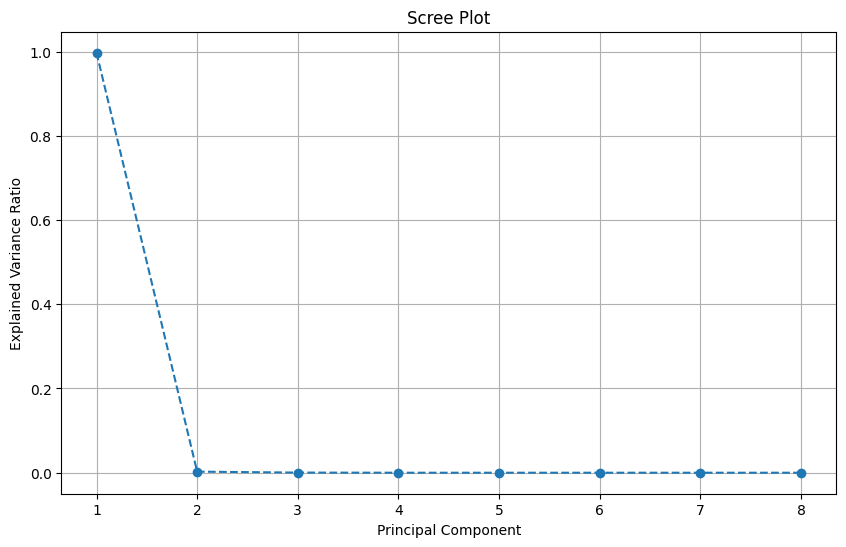

In [57]:
# Plot Scree Chart
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(np.arange(1, len(explained_variance) + 1, 1))
plt.grid()
plt.show()

In [60]:
# 최적의 주성분 개수 선택 (예: 95% 이상의 분산을 설명하는 최소 주성분 개수)
# 컬럼별 설명된 분산 비율 확인
explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.9971206 , 0.00255562])

In [72]:
# 2개의 주성분으로 변환하기 
from sklearn.decomposition import PCA

# PCA 수행

pca = PCA(n_components=2)
pca_component = pca.fit_transform(X)
pca2 = pd.DataFrame(pca_component,columns = ['pca1','pca2'])
pca2

,pca1,pca2
0,36.098541,-0.489253
1,55.543320,-0.961889
2,15.640106,-2.951113
3,60.627914,-1.891408
4,14.440405,1.363163
...,...,...
644,-9.946296,-0.100626
645,-24.163179,2.044082
646,-10.612705,0.623194
647,-31.938109,-0.466057


In [21]:
# PCA 설명된 분산 비율 출력


array([0.90514573, 0.05062617])

In [86]:
# pc1, pc2로 결과 데이터프레임 생성 
pca2['cluster'] = df['cluster']
df

,OPS,ISO,SECA,TA,RC,RC/27,wOBA,XR,cluster,silhouette,player
0,0.917819,0.149660,0.297052,0.976667,100.354529,8.286154,0.400138,92.804,0,0.469920,2000박종호
1,1.017141,0.264392,0.379531,1.063830,115.473840,9.306847,0.431993,105.000,0,0.683237,2000김동주
2,0.931997,0.195062,0.274074,0.931655,86.204956,8.224501,0.400969,77.820,2,0.592959,2000브리또
3,1.031229,0.284188,0.423077,1.110092,119.916981,9.811389,0.436688,107.594,0,0.664014,2000송지만
4,0.932665,0.231504,0.324582,0.923588,82.605677,7.125729,0.394586,80.284,2,0.643264,2000데이비스
...,...,...,...,...,...,...,...,...,...,...,...
644,0.857000,0.228571,0.377143,0.884328,64.894286,6.441712,0.369291,63.468,2,0.150327,2014이범호
645,0.733000,0.150358,0.276850,0.676647,53.028291,4.138046,0.319970,55.644,1,0.669427,2014모창민
646,0.767000,0.151134,0.355164,0.818182,64.147759,5.463689,0.336344,63.404,2,0.087227,2014오지환
647,0.655000,0.063205,0.146727,0.539359,48.898621,3.520701,0.293759,48.544,1,0.723784,2014조동화


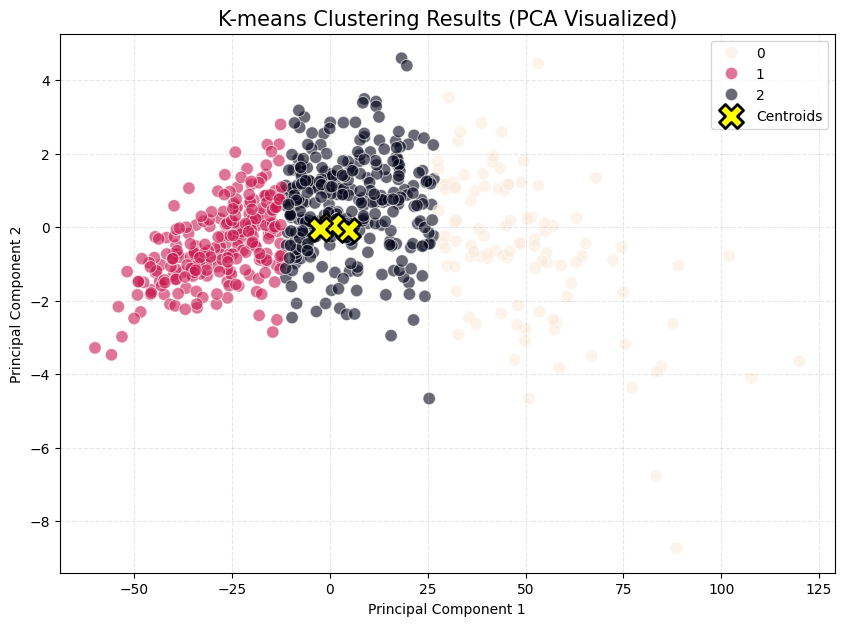

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples


# 5. 중심점(Centroids)을 PCA 공간으로 변환
# 학습된 모델의 중심점을 PCA 축으로 투영시켜야 데이터와 위치가 맞습니다.
centroids_pca = pca.transform(kmeans.cluster_centers_)

# --- 시각화 시작 ---
plt.figure(figsize=(10, 7))

# (1) 데이터 산점도
sns.scatterplot(
    data=pca2, 
    x='pca1', 
    y='pca2', 
    hue='cluster', 
    palette='rocket_r', 
    alpha=0.6,
    s=80,
    edgecolor='w'
)

# (2) 중심점 시각화 (3개의 노란색 X)
plt.scatter(
    centroids_pca[:, 0], 
    centroids_pca[:, 1], 
    s=300, 
    c='yellow', 
    marker='X', 
    edgecolors='black',
    linewidth=2,
    label='Centroids'
)

plt.title('K-means Clustering Results (PCA Visualized)', fontsize=15)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

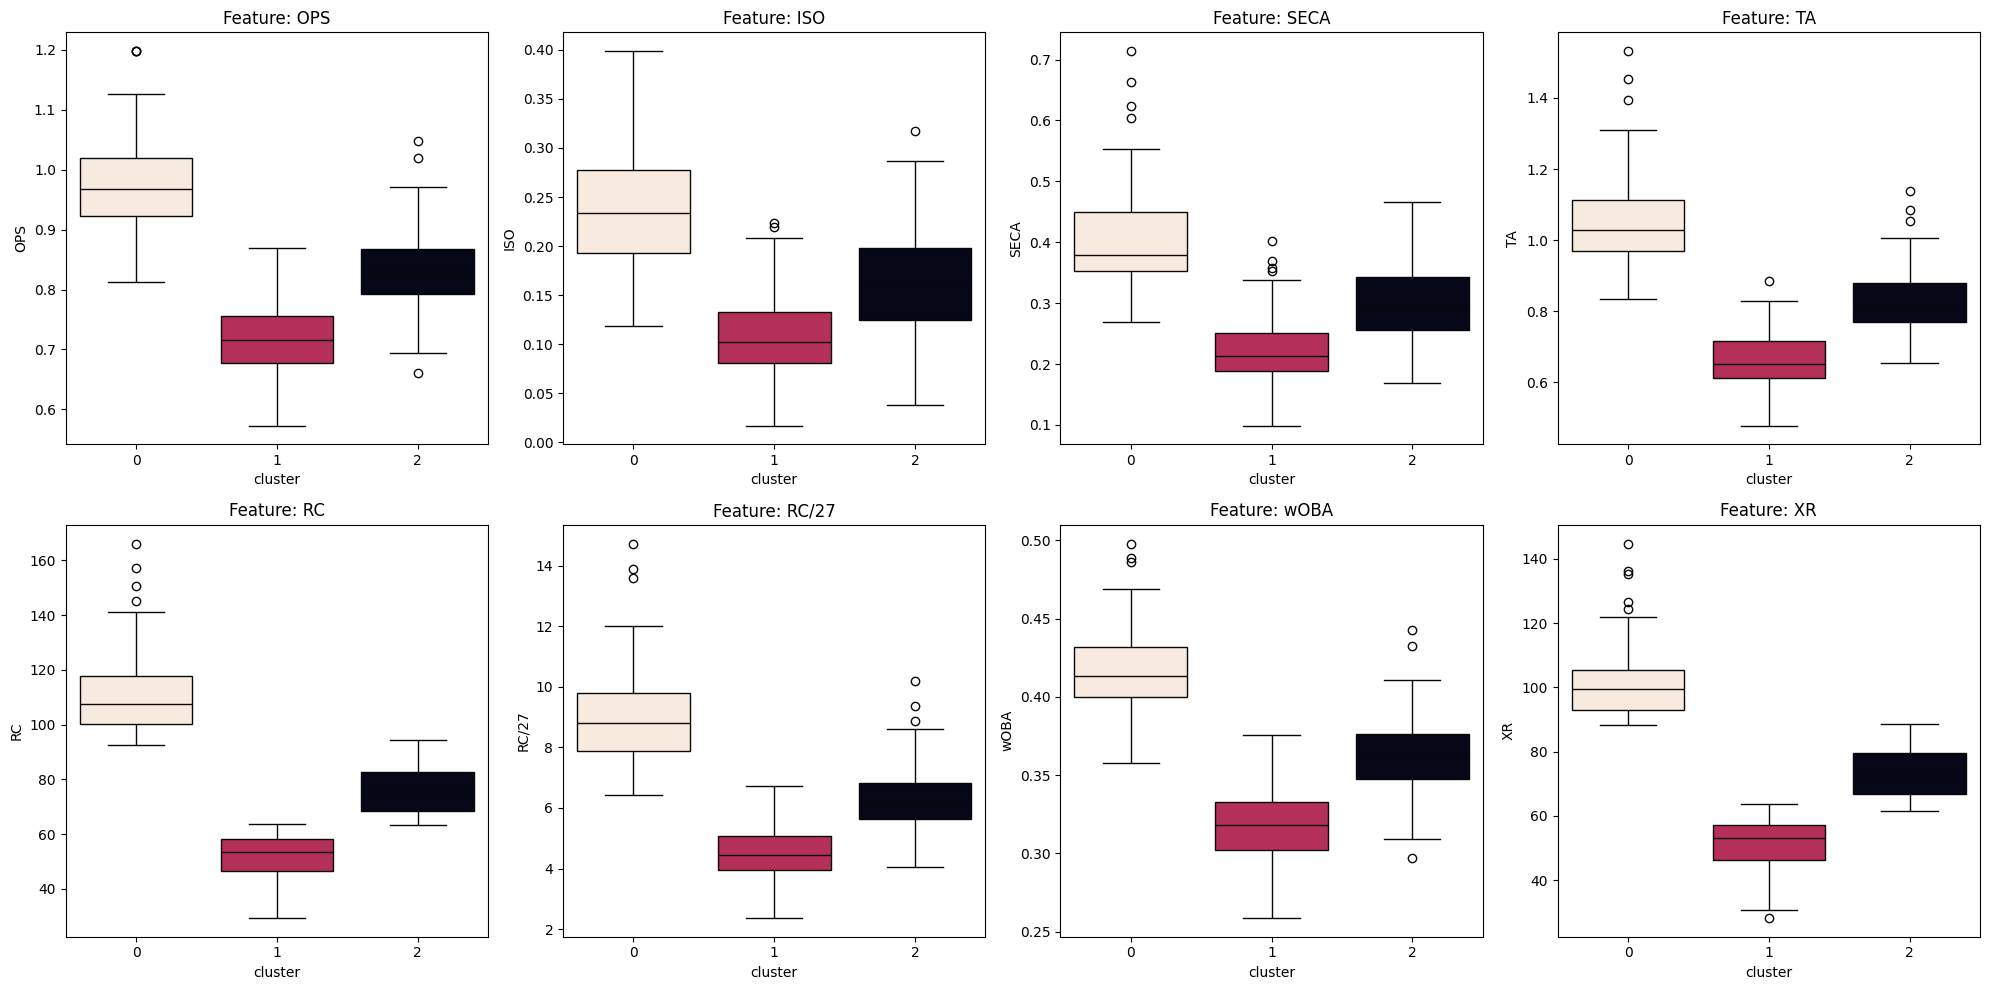

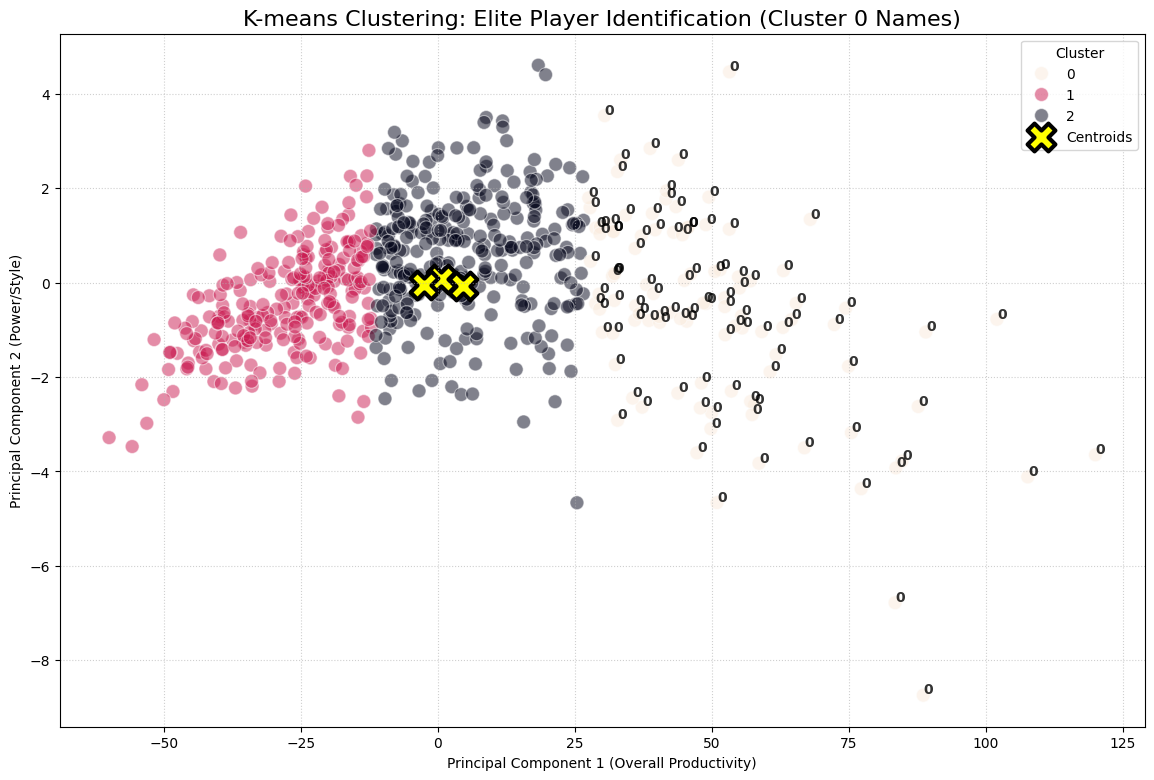


각 군집별 정체성이 가장 뚜렷한 대표 선수
    name  cluster  sil_score
 2009정근우        0   0.685948
 2007전준호        1   0.725000
2000심재학         2   0.717977


In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples


# --- [시각화 1: 피처별 박스플롯] ---
features = ['OPS', 'ISO', 'SECA', 'TA', 'RC', 'RC/27', 'wOBA', 'XR']
plt.figure(figsize=(20, 10))
for i, col in enumerate(features):
    plt.subplot(2, 4, i+1)
    # 경고 해결: hue 할당 및 legend 제거
    sns.boxplot(x='cluster', y=col, data=df, hue='cluster', 
                palette='rocket_r', legend=False)
    plt.title(f'Feature: {col}')
plt.tight_layout()
plt.show()

# --- [시각화 2: PCA 스캐터 플롯 + Cluster 0 이름 표시] ---
plt.figure(figsize=(14, 9))

# 전체 데이터 점 그리기
sns.scatterplot(
    data=pca2, x='pca1', y='pca2', hue='cluster', 
    palette='rocket_r', alpha=0.5, s=100, edgecolor='white'
)

# [핵심] Cluster 0(엘리트 군집) 선수 이름만 텍스트로 추가
for i in range(pca2.shape[0]):
    if pca2.loc[i, 'cluster'] == 0:
        plt.text(
            x=pca2.loc[i, 'pca1'] + 0.03, 
            y=pca2.loc[i, 'pca2'] + 0.03, 
            s=pca2.loc[i, 'cluster'], 
            fontsize=10, weight='bold', alpha=0.8
        )

# 중심점(Centroids) 표시
plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1], 
    s=400, c='yellow', marker='X', edgecolors='black', linewidth=3, label='Centroids'
)

plt.title('K-means Clustering: Elite Player Identification (Cluster 0 Names)', fontsize=16)
plt.xlabel('Principal Component 1 (Overall Productivity)')
plt.ylabel('Principal Component 2 (Power/Style)')
plt.legend(title='Cluster')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# --- [군집별 대표 선수 출력] ---
sil_values = silhouette_samples(X, cluster)
temp_summary = pd.DataFrame({
    'name': df['player'], 
    'cluster': cluster, 
    'sil_score': sil_values
})
rep_players = temp_summary.loc[temp_summary.groupby('cluster')['sil_score'].idxmax()]

print("\n" + "="*50)
print("각 군집별 정체성이 가장 뚜렷한 대표 선수")
print("="*50)
print(rep_players.to_string(index=False))

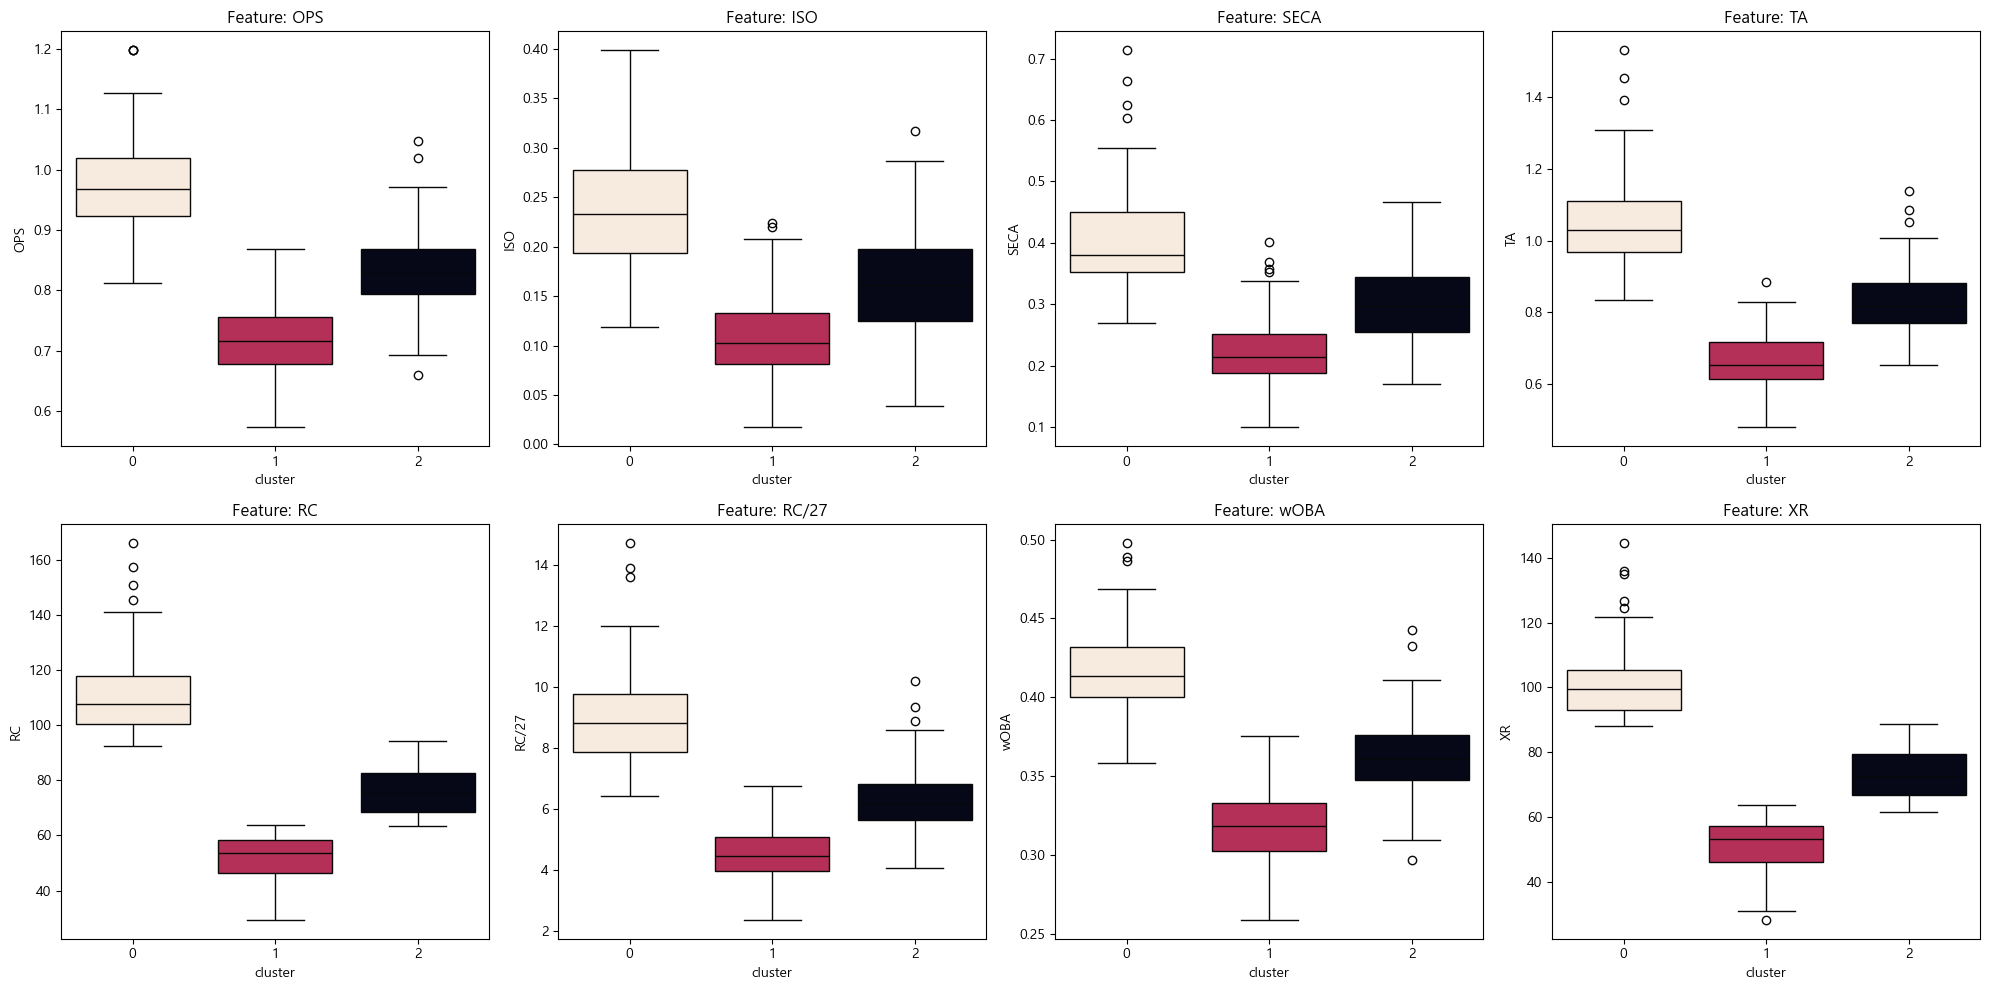

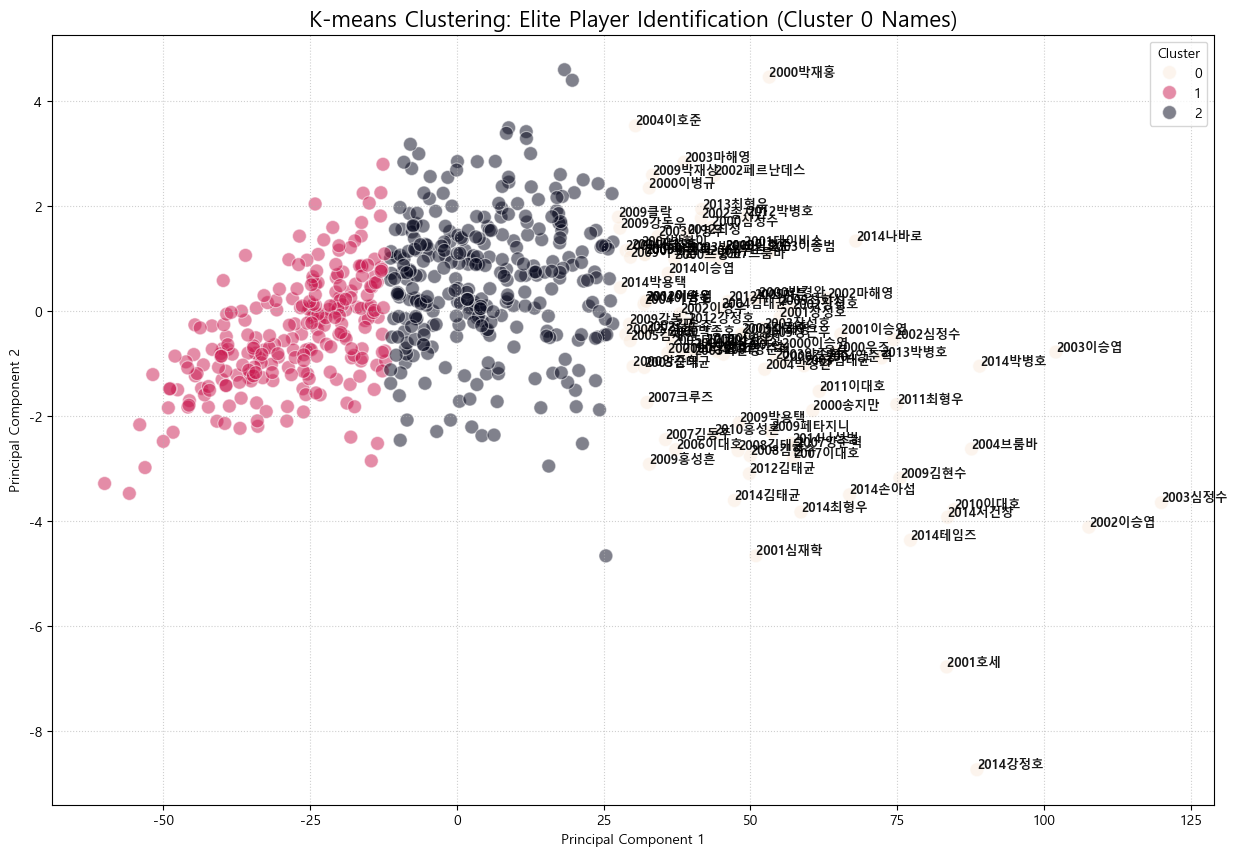


각 군집별 정체성이 가장 뚜렷한 대표 선수
  player  cluster  sil_score
 2009정근우        0   0.685948
 2007전준호        1   0.725000
2000심재학         2   0.717977


In [ ]:
# PCA를 전후 군집 결과 비교

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples

# 한글 폰트 설정 (이름 출력을 위해 필수)
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False

# 1. 시각화용 데이터프레임 정리 (pca2에 cluster와 player 정보가 있다고 가정)
# 만약 pca2가 넘파이 배열이라면 아래 한 줄을 실행하세요. 
# pca2 = pd.DataFrame(pca2, columns=['pca1', 'pca2'])

pca2['cluster'] = cluster  # 군집 결과 변수명 반영
pca2['player'] = df['player'].values  # 원본 데이터의 player 열 사용

# --- [시각화 1: 피처별 박스플롯] ---
features = ['OPS', 'ISO', 'SECA', 'TA', 'RC', 'RC/27', 'wOBA', 'XR']
plt.figure(figsize=(20, 10))
for i, col in enumerate(features):
    plt.subplot(2, 4, i+1)
    # df 데이터 사용, hue에 cluster 할당하여 경고 해결
    sns.boxplot(x='cluster', y=col, data=df, hue='cluster', 
                palette='rocket_r', legend=False)
    plt.title(f'Feature: {col}')
plt.tight_layout()
plt.show()

# --- [시각화 2: PCA 스캐터 플롯 + Cluster 0 전원 이름 표시] ---
plt.figure(figsize=(15, 10))

# 전체 데이터 점 그리기
sns.scatterplot(
    data=pca2, x='pca1', y='pca2', hue='cluster', 
    palette='rocket_r', alpha=0.5, s=100, edgecolor='white'
)

# [핵심] Cluster 0(엘리트 군집) 선수들의 'player' 이름 표시
for i in range(pca2.shape[0]):
    if pca2.loc[i, 'cluster'] == 0:
        plt.text(
            x=pca2.loc[i, 'pca1'] + 0.02, 
            y=pca2.loc[i, 'pca2'] + 0.02, 
            s=pca2.loc[i, 'player'],  # 변수명 player 반영
            fontsize=9, weight='bold', alpha=0.9
        )

plt.title('KBO 타자 생산성 군집화 결과 (PCA)', fontsize=16)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# --- [군집별 대표 선수 출력] ---
sil_values = silhouette_samples(X, cluster)
temp_summary = pd.DataFrame({
    'player': df['player'], 
    'cluster': cluster, 
    'sil_score': sil_values
})
rep_players = temp_summary.loc[temp_summary.groupby('cluster')['sil_score'].idxmax()]
